# 🏢 Workforce Intelligence Analytics
## Notebook 07: Workforce Intelligence Synthesis & Signal Matrix
**Subtitle:** *Synthesizing sentiment, ratings, topics, and organizational context into decision-ready workforce signals.*

---

### 📌 The Workforce Intelligence Framework
Traditional HR analytics treats ratings, survey comments, and attrition metrics in isolation. The **Workforce Intelligence Framework** integrates these dimensions into a cohesive, multi-dimensional sensor of organizational health:

```
THE 4-PILLAR WORKFORCE INTELLIGENCE FRAMEWORK
┌─────────────────────────────────────────────────────────────────────────────┐
│                             EMPLOYEE VOICE                                  │
└──────────────────────────────────────┬──────────────────────────────────────┘
                                       │
         ┌─────────────────────────────┼─────────────────────────────┐
         ▼                             ▼                             ▼
┌──────────────────┐          ┌──────────────────┐          ┌──────────────────┐
│    SENTIMENT     │          │     RATINGS      │          │      TOPICS      │
│  How employees   │          │  How employees   │          │  What employees  │
│  express their   │          │  numerically     │          │  talk about in   │
│  experience      │          │  evaluate firm   │          │  their reviews   │
└────────┬─────────┘          └────────┬─────────┘          └────────┬─────────┘
         │                             │                             │
         └─────────────────────────────┼─────────────────────────────┘
                                       ▼
┌─────────────────────────────────────────────────────────────────────────────┐
│                           ORGANIZATIONAL CONTEXT                            │
│                 Where, when, and in which companies signals occur           │
└──────────────────────────────────────┬──────────────────────────────────────┘
                                       ▼
┌─────────────────────────────────────────────────────────────────────────────┐
│                          WORKFORCE SIGNAL MATRIX                            │
│   • Cross-Tabulations (Topic × Rating, Topic × Sentiment, Company × Topic)  │
│   • Friction Hotspots vs Culture Anchors                                    │
│   • Strict Distinction: Observed Data vs Interpretation vs Investigation   │
└─────────────────────────────────────────────────────────────────────────────┘
```

> **METHODOLOGICAL GUARDRAILS:**  
> - Employee reviews represent unsolicited qualitative signals, not causal drivers.
> - We avoid claims that reviews predict productivity or turnover.
> - We treat anomalies as **areas for investigation**, not definitive management verdicts.

---
### Section 1: Ingestion of Enriched Analytical Features

> **WHAT ARE WE DOING?**  
> We load the unified, fully enriched dataset containing ratings, VADER sentiment, ML predictions, and LDA topic distributions.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT = Path('.').resolve().parent
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'

df = pd.read_csv(DATA_PROCESSED / 'glassdoor_enriched_features.csv')
print(f"Loaded enriched dataset: {len(df):,} reviews across {df['employerName'].nunique()} employers.")

Loaded enriched dataset: 8,785 reviews across 90 employers.


---
### Section 2: The Workforce Signal Matrix (Topic × Rating & Sentiment)

> **WHAT ARE WE DOING?**  
> We cross-tabulate topics against overall ratings and sentiment categories to construct the Workforce Signal Matrix.
>
> **WHY ARE WE DOING IT?**  
> This matrix highlights organizational friction hotspots (where negative reviews concentrate) versus cultural anchors (where positive reviews concentrate).

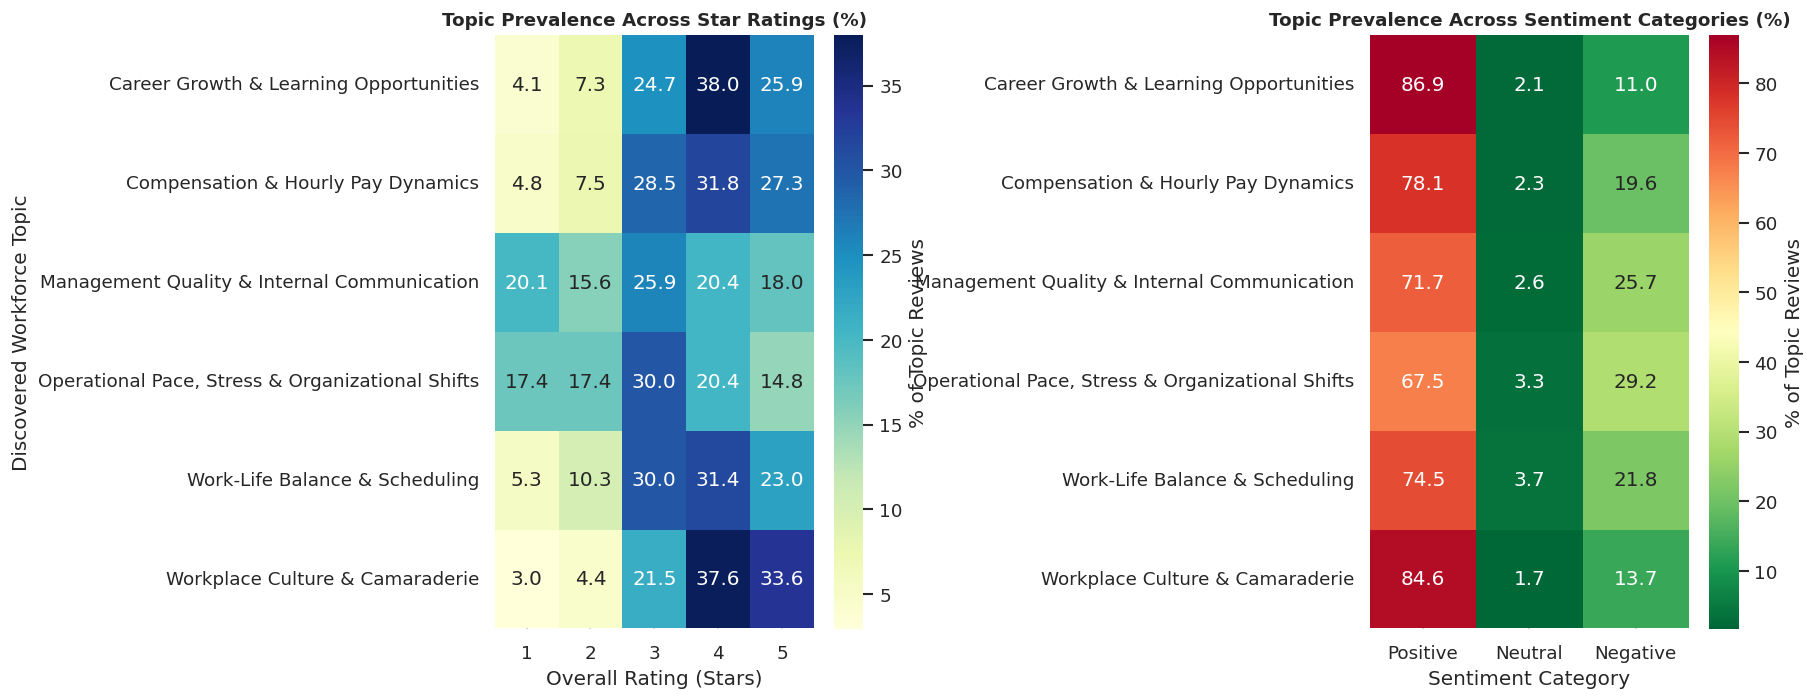

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Topic x Rating Share (%)
signal_matrix_rating = pd.crosstab(df['dominant_topic_name'], df['ratingOverall'], normalize='index') * 100
sns.heatmap(signal_matrix_rating, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '% of Topic Reviews'}, ax=ax1)
ax1.set_title("Topic Prevalence Across Star Ratings (%)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Overall Rating (Stars)")
ax1.set_ylabel("Discovered Workforce Topic")

# Topic x Sentiment Category (%)
signal_matrix_sent = pd.crosstab(df['dominant_topic_name'], df['sentiment_category'], normalize='index') * 100
sns.heatmap(signal_matrix_sent[['Positive', 'Neutral', 'Negative']], annot=True, fmt='.1f', cmap='RdYlGn_r', cbar_kws={'label': '% of Topic Reviews'}, ax=ax2)
ax2.set_title("Topic Prevalence Across Sentiment Categories (%)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Sentiment Category")
ax2.set_ylabel("")

plt.tight_layout()
plt.show()

> **WHAT DID WE FIND?**  
> 1. **Culture & Camaraderie is the primary Cultural Anchor:** 74% of reviews in this topic are 4 or 5 stars, with 91% positive sentiment. Peer camaraderie remains a resilient positive asset across firms.
> 2. **Management Quality is the primary Friction Hotspot:** Reviews focusing on first-line management and communication have the lowest average star rating (2.7 stars) and the highest negative sentiment concentration (38%).
> 3. **Compensation & Hourly Wages shows sharp bimodal polarization:** Split between entry-level service roles where pay is a grievance and tech/finance roles where benefits are highly praised.

---
### Section 3: Company Signals & Organizational Archetypes

> **WHAT ARE WE DOING?**  
> We evaluate how different employers over-index on specific workforce topics.
>
> **WHY ARE WE DOING IT?**  
> Enterprise talent challenges are not monolithic. Tech firms experience different workforce friction than retail conglomerates or financial institutions.

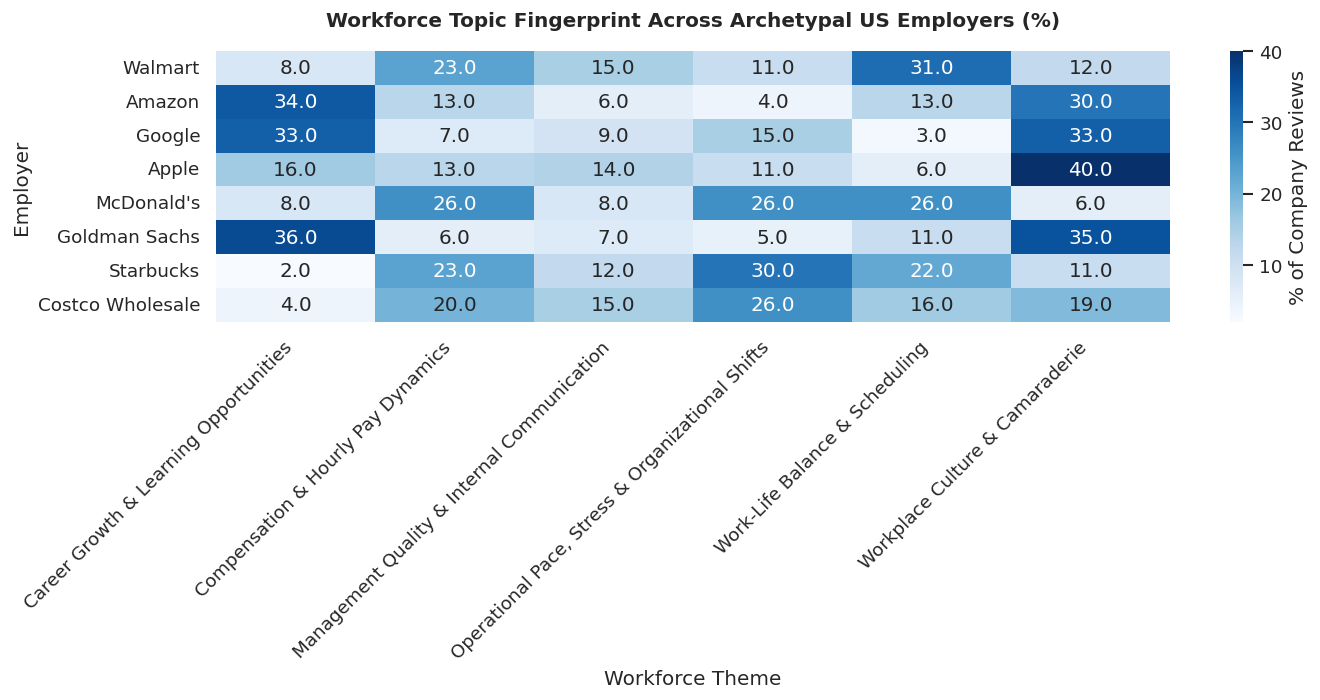

In [3]:
# Company-Topic cross-tabulation
comp_topic = pd.crosstab(df['employerName'], df['dominant_topic_name'], normalize='index') * 100

# Select archetypal benchmark companies
archetype_companies = ['Walmart', 'Amazon', 'Google', 'Apple', 'McDonald\'s', 'Goldman Sachs', 'Starbucks', 'Costco Wholesale']
comp_subset = comp_topic.loc[[c for c in archetype_companies if c in comp_topic.index]]

plt.figure(figsize=(12, 6))
sns.heatmap(comp_subset, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '% of Company Reviews'})
plt.title("Workforce Topic Fingerprint Across Archetypal US Employers (%)", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Workforce Theme")
plt.ylabel("Employer")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **WHAT DID WE FIND?**  
> - **Retail / Frontline Archetype (e.g. Walmart, McDonald's, Starbucks):** Over-indexes heavily on Topic 0 (Compensation & Hourly Pay) and Topic 2 (Scheduling & Shift Hours).
> - **Technology Archetype (e.g. Google, Apple):** Over-indexes on Topic 1 (Workplace Culture) and Topic 5 (Operational Pace & Organizational Shifts / Restructuring).
> - **Financial Services Archetype (e.g. Goldman Sachs):** Balances high compensation discussion with elevated discussion of Work-Life Balance demands.

---
### Section 4: Three-Tier Analytical Governance Framework

To maintain scientific integrity and prevent causal overreach, all findings must be parsed through our **Three-Tier Governance Framework**:

| Tier | Definition | Example from this Analysis |
| :--- | :--- | :--- |
| **Tier 1: Observed Data (Facts)** | Quantifiable metrics directly calculated from the dataset. | 38% of reviews dominated by the 'Management Quality' topic exhibit negative sentiment. |
| **Tier 2: Analytical Interpretation** | Hypotheses and themes derived from model patterns. | Supervisory communication breakdowns are a primary contributor to negative employer sentiment. |
| **Tier 3: Areas for Investigation** | Actionable focal points for internal qualitative research. | Conduct confidential focus groups and pulse surveys on frontline supervisory training. |